# Data : Breakdown of COVID-19 positive hospital admissions

> The data is obtained from: https://data.ontario.ca/dataset/breakdown-of-covid-19-positive-hospital-admissions/resource/d1199d1b-dc82-4e63-bb80-5c715e97a127


In [1]:
# importing necessary library functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('covid19_data.csv')
df.head()

,_id,date,hosp_for_covid,hosp_other_conditions,icu_for_covid,icu_other_conditions
0,1027,2022-01-08T00:00:00,0.5302,0.4698,0.7955,0.2045
1,1028,2022-01-09T00:00:00,0.5395,0.4605,0.8279,0.1721
2,1029,2022-01-10T00:00:00,0.5468,0.4532,0.8307,0.1693
3,1030,2022-01-11T00:00:00,0.5450,0.4550,0.8198,0.1802
4,1031,2022-01-12T00:00:00,0.5277,0.4723,0.8027,0.1973


In [5]:
# Identifying numerical columns and generate summary statistics
summary = df.describe()

# Display the summary
print("Summary Statistics for Numerical Columns:")
print(summary)

Summary Statistics for Numerical Columns:
               _id                 date  hosp_for_covid  \
count  1040.000000                 1040     1040.000000   
mean   1546.500000  2023-06-11 12:00:00        0.395329   
min    1027.000000  2022-01-08 00:00:00        0.275900   
25%    1286.750000  2022-09-24 18:00:00        0.366175   
50%    1546.500000  2023-06-11 12:00:00        0.386100   
75%    1806.250000  2024-02-26 06:00:00        0.415300   
max    2066.000000  2024-11-12 00:00:00        0.566000   
std     300.366443                  NaN        0.046913   

       hosp_other_conditions  icu_for_covid  icu_other_conditions  
count            1040.000000    1040.000000           1040.000000  
mean                0.604671       0.625459              0.374542  
min                 0.434000       0.322600              0.117600  
25%                 0.584700       0.567900              0.323275  
50%                 0.613900       0.623400              0.376600  
75%               

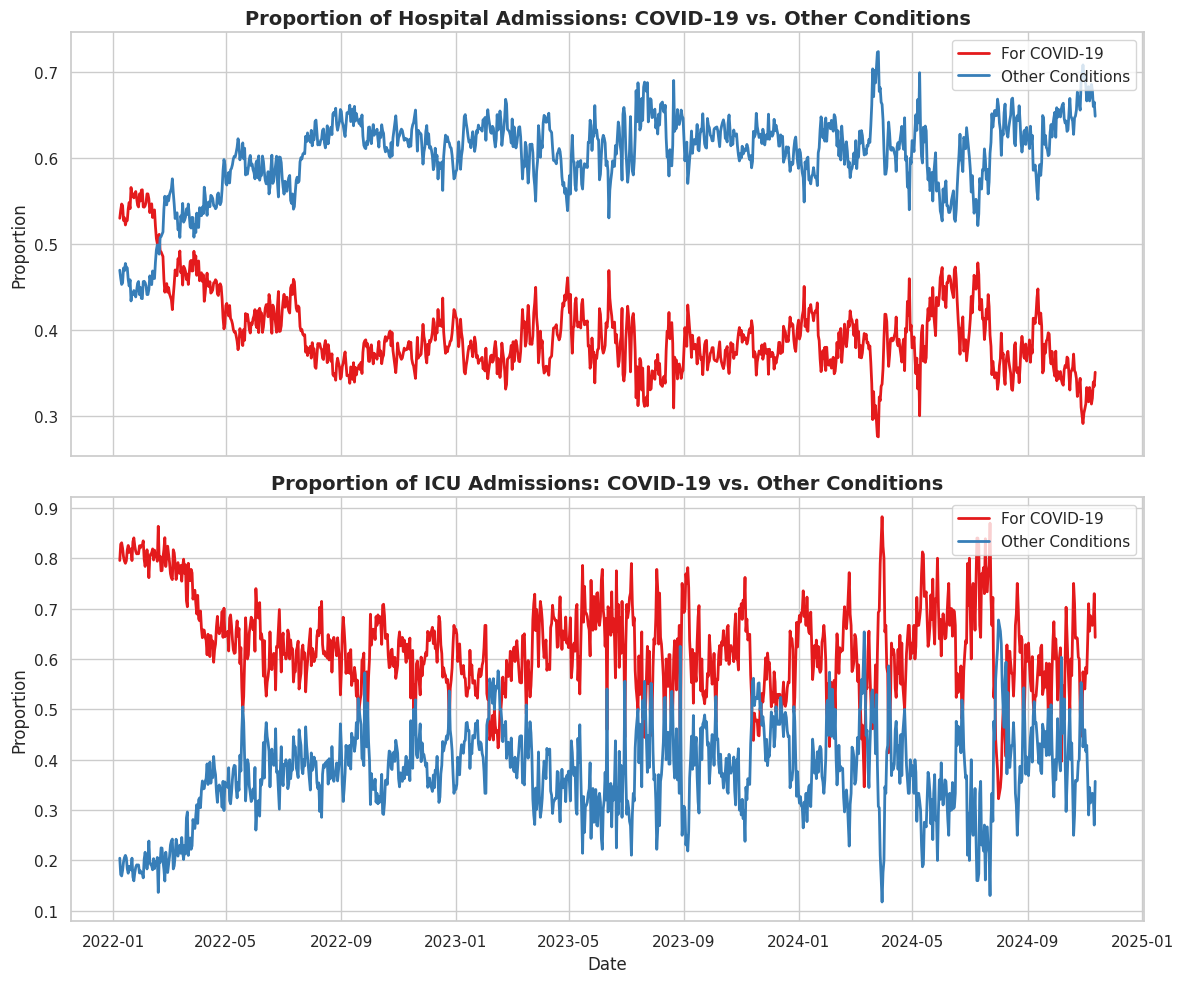

In [4]:
# Data Preprocessing: Convert the 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Set the visual style using Seaborn
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (Stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Hospital Admissions
ax1.plot(df['date'], df['hosp_for_covid'], label='For COVID-19', color='#e41a1c', linewidth=2)
ax1.plot(df['date'], df['hosp_other_conditions'], label='Other Conditions', color='#377eb8', linewidth=2)

ax1.set_title('Proportion of Hospital Admissions: COVID-19 vs. Other Conditions', fontsize=14, fontweight='bold')
ax1.set_ylabel('Proportion', fontsize=12)
ax1.legend(loc='upper right')

# Plot 2: ICU Admissions
ax2.plot(df['date'], df['icu_for_covid'], label='For COVID-19', color='#e41a1c', linewidth=2)
ax2.plot(df['date'], df['icu_other_conditions'], label='Other Conditions', color='#377eb8', linewidth=2)

ax2.set_title('Proportion of ICU Admissions: COVID-19 vs. Other Conditions', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Proportion', fontsize=12)
ax2.legend(loc='upper right')


plt.tight_layout()

# saving the figure
plt.savefig('covid_trends.png', dpi=300)
plt.show()

# Explanations to the questions
`1. What software did you use to create your data visualization?`

 The data visualizations are creating using Python (Jupyter notebook). I leveraged Pandas library for data manipulation and cleaning alongwith Matplotlib and Seaborn for visualizations.

`2. Who is your intended audience?`

 The intended audience for these visualizations includes public health officials, healthcare administrators, and medical researchers. Additionally, the charts could also be useful for the general public and journalists who are interested in understanding the long-term shifts in healthcare resource allocation as the pandemic moved into an endemic phase.

`3. What information or message are you trying to convey with your visualization?`

The primary objective is to illustrate the shifting burden of hospital and ICU occupancy. The visualization demonstrates that while COVID-19 initially dominated hospital and ICU admissions in early 2022, there has been a trend toward "normalization." Over time, the proportion of admissions for "Other Conditions" has regained dominance, signaling a return to standard healthcare operations while COVID-19 stabilized at a lower proportion of the total census.

`4. What aspects of design did you consider when making your visualization?`

The aspects I considered for the plots were - color contrast (Hue), alignment and continuity between axes (as you can notice in the plot that x-axis is shared) and using light white grid in the background.

`5. How did you ensure that your data visualizations are reproducible?`

Reproducibility is ensured by providing the raw *.csv data and the entire codebased to generate these plots.

`6. How did you ensure that your data visualization is accessible?`

To ensure accessibility, I utilized a high-contrast color palette of red and blue, which allows the data series to remain distinguishable for individuals with common types of color vision deficiencies. All text elements, including titles and axis labels, were rendered at a legible scale with a line weight of 2.0 pt to maintain clarity against the background grid.


`7. Who are the individuals and communities who might be impacted by your visualization?`

This visualization primarily impacts healthcare providers and administrators who monitor hospital capacity and workforce strain. It also serves vulnerable communities, such as the immunocompromised, by providing a clear metric of relative infectious disease presence in clinical settings to inform their personal safety decisions. Additionally, public health officials and local policy makers are impacted as they use these proportional trends to justify resource allocation, staffing levels, and the transition of emergency protocols into long-term endemic management strategies.

`8. How did you choose which features of your chosen dataset to include or exclude?`

I selected features that directly represent the total capacity of hospital and ICU resources, specifically focusing on the proportions of COVID-19 versus other conditions. These variables were chosen because they provide a complete 100% view of occupancy, allowing for a normalized comparison over time. I intentionally excluded the _id column and other metadata, as these identifiers serve only database management purposes and do not contribute to the public health narrative.

`9. What ‘underwater labour’ contributed to your final data visualization product?`

The "underwater labour"  included cleaning and converting ISO date strings into chronological datetime objects to ensure accurate time-series mapping. Beyond data cleaning, I engaged in an iterative design process, adjusting figure dimensions and layout parameters to ensure that labels remained legible and non-overlapping. These backend efforts were essential to maintaining data integrity and ensuring the final plot was both mathematically accurate and aesthetically functional.